In [9]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [10]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, models
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm


In [11]:
from torch.utils.data import Dataset

class VideoDataset(Dataset):
    def __init__(self, root_dir, transform=None, sequence_length=32):
        self.root_dir = root_dir
        self.transform = transform
        self.sequence_length = sequence_length
        self.samples = []
        self.labels = []

        for label, class_name in enumerate(["NonViolence", "Violence"]):
            class_dir = os.path.join(root_dir, class_name)
            for folder in sorted(os.listdir(class_dir)):
                folder_path = os.path.join(class_dir, folder)
                if len(os.listdir(folder_path)) >= sequence_length:
                    self.samples.append(folder_path)
                    self.labels.append(label)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        folder_path = self.samples[idx]
        label = self.labels[idx]
        frames = []
        for i in range(self.sequence_length):
            img_path = os.path.join(folder_path, f"frame_{i:03d}.jpg")
            img = Image.open(img_path).convert("RGB")
            if self.transform:
                img = self.transform(img)
            frames.append(img)
        frames = torch.stack(frames)  # (T, C, H, W)
        return frames, label


In [12]:
import shutil
import os
from google.colab import drive

drive.mount('/content/drive')

source_path = "/content/drive/MyDrive/archive/Real Life Violence Dataset"
destination_path = "/content/Videos/Real Life Violence Dataset"
shutil.copytree(source_path, destination_path, dirs_exist_ok=True)

print("✅ Videos copied successfully.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Videos copied successfully.


In [13]:
import cv2
import numpy as np
import os
from tqdm import tqdm

video_root = "/content/Videos/Real Life Violence Dataset"
output_root = "/content/processed_frames"
sequence_length = 32
categories = ["NonViolence", "Violence"]

os.makedirs(output_root, exist_ok=True)

def extract_frames_from_video(video_path, output_folder, num_frames=32):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames < num_frames:
        return False
    frame_indices = np.linspace(0, total_frames - 1, num=num_frames, dtype=int)
    os.makedirs(output_folder, exist_ok=True)
    for idx, frame_index in enumerate(frame_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
        ret, frame = cap.read()
        if not ret:
            continue
        frame_path = os.path.join(output_folder, f"frame_{idx:03d}.jpg")
        cv2.imwrite(frame_path, frame)
    cap.release()
    return True

for category in categories:
    input_dir = os.path.join(video_root, category)
    output_category_dir = os.path.join(output_root, category)
    os.makedirs(output_category_dir, exist_ok=True)
    video_list = sorted(os.listdir(input_dir))
    print(f"🔍 Processing category: {category}")
    for idx, video_name in enumerate(tqdm(video_list)):
        video_path = os.path.join(input_dir, video_name)
        target_folder = os.path.join(output_category_dir, f"video_{idx}")
        success = extract_frames_from_video(video_path, target_folder, sequence_length)
        if not success:
            print(f"⚠️ Skipped video (too short): {video_name}")


🔍 Processing category: NonViolence


 94%|█████████▎| 937/1002 [05:49<00:08,  7.29it/s]

⚠️ Skipped video (too short): NV_940.mp4


100%|██████████| 1002/1002 [06:12<00:00,  2.69it/s]


🔍 Processing category: Violence


100%|██████████| 1000/1000 [13:06<00:00,  1.27it/s]


In [14]:
from torch.utils.data import Dataset
from PIL import Image
import torch
import os

class VideoDataset(Dataset):
    def __init__(self, root_dir, transform=None, sequence_length=32):
        self.root_dir = root_dir
        self.transform = transform
        self.sequence_length = sequence_length
        self.samples = []
        self.labels = []

        for label, class_name in enumerate(["NonViolence", "Violence"]):
            class_dir = os.path.join(root_dir, class_name)
            for folder in sorted(os.listdir(class_dir)):
                folder_path = os.path.join(class_dir, folder)
                if len(os.listdir(folder_path)) >= sequence_length:
                    self.samples.append(folder_path)
                    self.labels.append(label)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        folder_path = self.samples[idx]
        label = self.labels[idx]
        frames = []
        for i in range(self.sequence_length):
            img_path = os.path.join(folder_path, f"frame_{i:03d}.jpg")
            img = Image.open(img_path).convert("RGB")
            if self.transform:
                img = self.transform(img)
            frames.append(img)
        frames = torch.stack(frames)  # shape = (T, C, H, W)
        return frames, label


In [15]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

dataset = VideoDataset("/content/processed_frames", transform=transform)
print(f"Total videos: {len(dataset)}")


Total videos: 1997


In [16]:
import torch.nn as nn
from torchvision import models

class MoBiLSTM(nn.Module):
    def __init__(self, hidden_dim=768, num_classes=2, num_layers=2):
        super(MoBiLSTM, self).__init__()
        base_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        for name, param in base_model.named_parameters():
            param.requires_grad = "layer4" in name or "fc" in name

        self.cnn = nn.Sequential(*list(base_model.children())[:-1])  # Remove final FC
        self.lstm = nn.LSTM(input_size=2048,
                            hidden_size=hidden_dim,
                            num_layers=num_layers,
                            bidirectional=True,
                            batch_first=True,
                            dropout=0.3)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):  # x: (B, T, C, H, W)
        B, T, C, H, W = x.size()
        x = x.view(B * T, C, H, W)
        features = self.cnn(x).view(B, T, -1)  # shape: (B, T, 2048)
        lstm_out, _ = self.lstm(features)
        out = self.dropout(lstm_out[:, -1, :])
        return self.fc(out)


🔁 بدء التدريب - Fold 1


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 204MB/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
[Fold 1] Epoch 1/30 [Val]: 100%|██████████| 50/50 [00:39<00:00,  1.26it/s]



📊 Fold 1 | Epoch 1
📉 Train Loss: 0.4020 | ✅ Train Acc: 0.8710
🧪  Val Loss : 0.2865 | 🎯 Val Acc  : 0.9600
💾 أفضل نموذج تم حفظه.


[Fold 1] Epoch 2/30 [Val]: 100%|██████████| 50/50 [00:39<00:00,  1.26it/s]



📊 Fold 1 | Epoch 2
📉 Train Loss: 0.2664 | ✅ Train Acc: 0.9662
🧪  Val Loss : 0.2345 | 🎯 Val Acc  : 0.9850
💾 أفضل نموذج تم حفظه.


...


📊 Fold 1 | Epoch 11
📉 Train Loss: 0.2031 | ✅ Train Acc: 0.9981
🧪  Val Loss : 0.2147 | 🎯 Val Acc  : 0.9925


[Fold 1] Epoch 12/30 [Val]: 100%|██████████| 50/50 [00:39<00:00,  1.28it/s]



📊 Fold 1 | Epoch 12
📉 Train Loss: 0.2073 | ✅ Train Acc: 0.9956
🧪  Val Loss : 0.2276 | 🎯 Val Acc  : 0.9850


[Fold 1] Epoch 13/30 [Val]: 100%|██████████| 50/50 [00:39<00:00,  1.27it/s]



📊 Fold 1 | Epoch 13
📉 Train Loss: 0.2067 | ✅ Train Acc: 0.9962
🧪  Val Loss : 0.2262 | 🎯 Val Acc  : 0.9850
⏹️ تم التوقف المبكر.

------------------------------------------------------------
📄 تقرير التصنيف - Fold 1 (بعد تحميل أفضل وزن)
------------------------------------------------------------
              precision    recall  f1-score   support

  NonViolent       1.00      1.00      1.00       207
     Violent       0.99      0.99      0.99       193

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



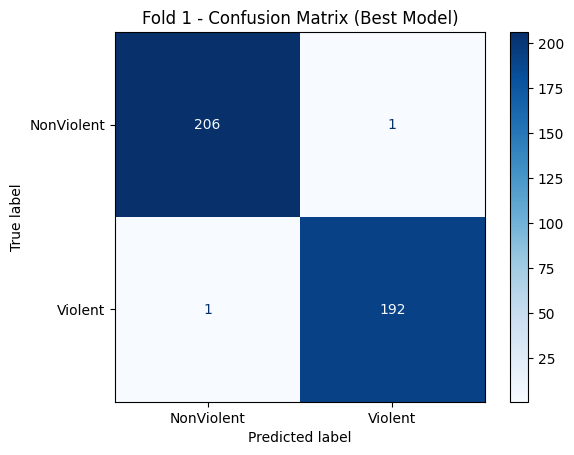

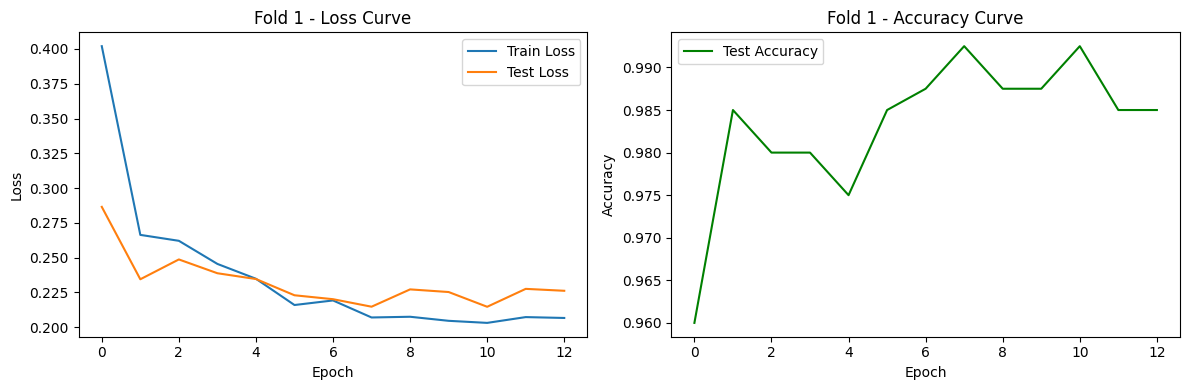

🔁 بدء التدريب - Fold 2


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
[Fold 2] Epoch 1/30 [Val]: 100%|██████████| 50/50 [00:40<00:00,  1.22it/s]



📊 Fold 2 | Epoch 1
📉 Train Loss: 0.4002 | ✅ Train Acc: 0.8704
🧪  Val Loss : 0.2459 | 🎯 Val Acc  : 0.9750
💾 أفضل نموذج تم حفظه.


[Fold 2] Epoch 2/30 [Val]: 100%|██████████| 50/50 [00:40<00:00,  1.23it/s]



📊 Fold 2 | Epoch 2
📉 Train Loss: 0.2756 | ✅ Train Acc: 0.9587
🧪  Val Loss : 0.2921 | 🎯 Val Acc  : 0.9400


...


📊 Fold 2 | Epoch 7
📉 Train Loss: 0.2105 | ✅ Train Acc: 0.9944
🧪  Val Loss : 0.2542 | 🎯 Val Acc  : 0.9750


[Fold 2] Epoch 8/30 [Val]: 100%|██████████| 50/50 [00:40<00:00,  1.23it/s]



📊 Fold 2 | Epoch 8
📉 Train Loss: 0.2101 | ✅ Train Acc: 0.9950
🧪  Val Loss : 0.2722 | 🎯 Val Acc  : 0.9675


[Fold 2] Epoch 9/30 [Val]: 100%|██████████| 50/50 [00:40<00:00,  1.23it/s]



📊 Fold 2 | Epoch 9
📉 Train Loss: 0.2026 | ✅ Train Acc: 0.9975
🧪  Val Loss : 0.2512 | 🎯 Val Acc  : 0.9750
⏹️ تم التوقف المبكر.

------------------------------------------------------------
📄 تقرير التصنيف - Fold 2 (بعد تحميل أفضل وزن)
------------------------------------------------------------
              precision    recall  f1-score   support

  NonViolent       0.99      0.97      0.98       193
     Violent       0.98      0.99      0.98       207

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



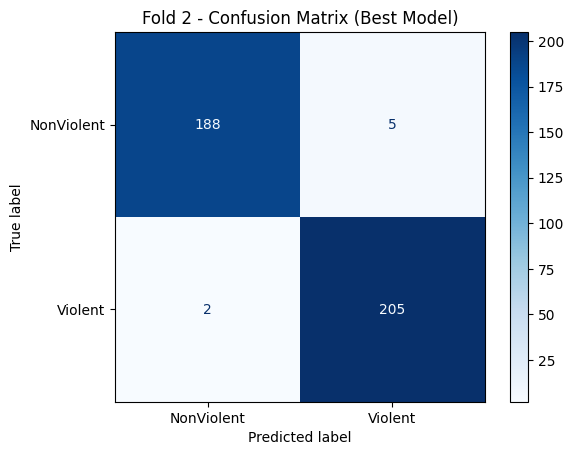

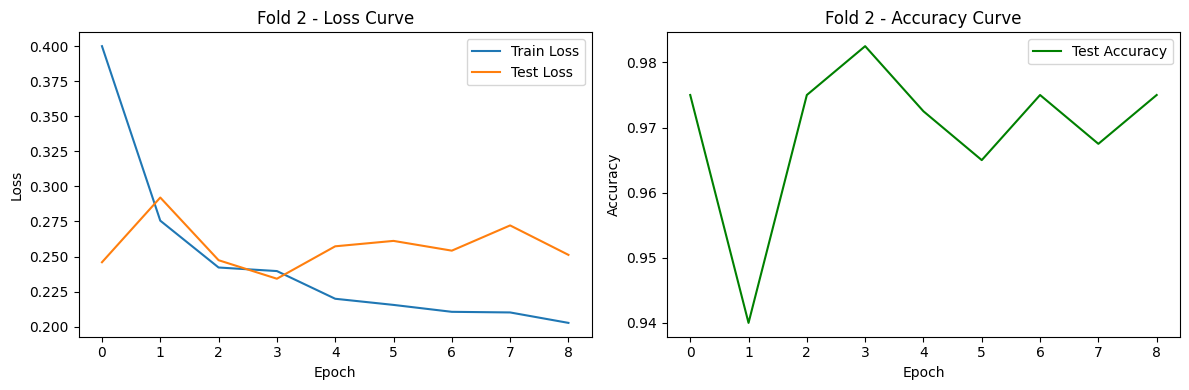

🔁 بدء التدريب - Fold 3


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
[Fold 3] Epoch 1/30 [Val]: 100%|██████████| 50/50 [00:40<00:00,  1.23it/s]



📊 Fold 3 | Epoch 1
📉 Train Loss: 0.4036 | ✅ Train Acc: 0.8767
🧪  Val Loss : 0.3574 | 🎯 Val Acc  : 0.9198
💾 أفضل نموذج تم حفظه.


[Fold 3] Epoch 2/30 [Val]: 100%|██████████| 50/50 [00:40<00:00,  1.23it/s]



📊 Fold 3 | Epoch 2
📉 Train Loss: 0.2913 | ✅ Train Acc: 0.9506
🧪  Val Loss : 0.2605 | 🎯 Val Acc  : 0.9699
💾 أفضل نموذج تم حفظه.


...


📊 Fold 3 | Epoch 5
📉 Train Loss: 0.2186 | ✅ Train Acc: 0.9900
🧪  Val Loss : 0.2816 | 🎯 Val Acc  : 0.9574


[Fold 3] Epoch 6/30 [Val]: 100%|██████████| 50/50 [00:40<00:00,  1.23it/s]



📊 Fold 3 | Epoch 6
📉 Train Loss: 0.2205 | ✅ Train Acc: 0.9887
🧪  Val Loss : 0.2610 | 🎯 Val Acc  : 0.9699


[Fold 3] Epoch 7/30 [Val]: 100%|██████████| 50/50 [00:40<00:00,  1.24it/s]



📊 Fold 3 | Epoch 7
📉 Train Loss: 0.2120 | ✅ Train Acc: 0.9937
🧪  Val Loss : 0.2661 | 🎯 Val Acc  : 0.9624
⏹️ تم التوقف المبكر.

------------------------------------------------------------
📄 تقرير التصنيف - Fold 3 (بعد تحميل أفضل وزن)
------------------------------------------------------------
              precision    recall  f1-score   support

  NonViolent       0.98      0.96      0.97       213
     Violent       0.96      0.98      0.97       186

    accuracy                           0.97       399
   macro avg       0.97      0.97      0.97       399
weighted avg       0.97      0.97      0.97       399



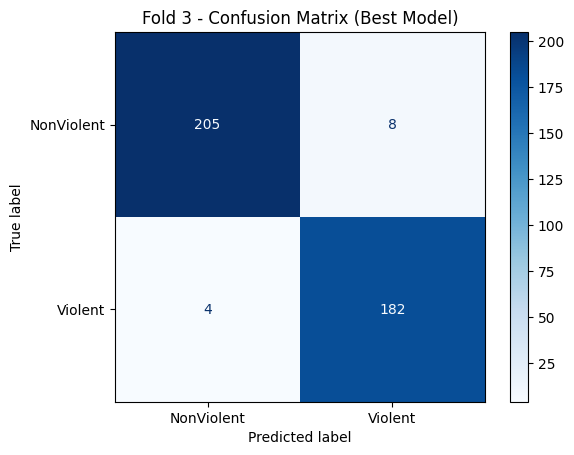

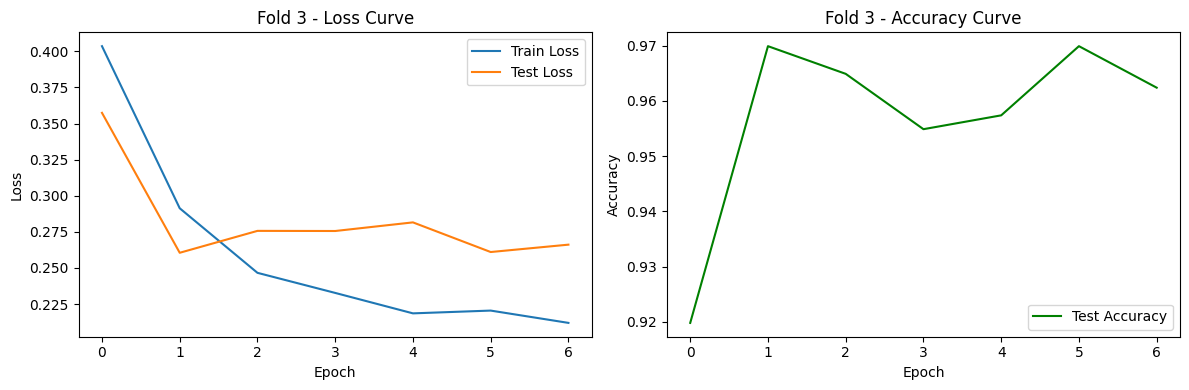

🔁 بدء التدريب - Fold 4


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
[Fold 4] Epoch 1/30 [Val]: 100%|██████████| 50/50 [00:40<00:00,  1.24it/s]



📊 Fold 4 | Epoch 1
📉 Train Loss: 0.3812 | ✅ Train Acc: 0.8949
🧪  Val Loss : 0.2657 | 🎯 Val Acc  : 0.9599
💾 أفضل نموذج تم حفظه.


[Fold 4] Epoch 2/30 [Val]: 100%|██████████| 50/50 [00:39<00:00,  1.25it/s]



📊 Fold 4 | Epoch 2
📉 Train Loss: 0.2745 | ✅ Train Acc: 0.9618
🧪  Val Loss : 0.2536 | 🎯 Val Acc  : 0.9724
💾 أفضل نموذج تم حفظه.


...


📊 Fold 4 | Epoch 6
📉 Train Loss: 0.2231 | ✅ Train Acc: 0.9875
🧪  Val Loss : 0.2435 | 🎯 Val Acc  : 0.9799


[Fold 4] Epoch 7/30 [Val]: 100%|██████████| 50/50 [00:40<00:00,  1.25it/s]



📊 Fold 4 | Epoch 7
📉 Train Loss: 0.2103 | ✅ Train Acc: 0.9944
🧪  Val Loss : 0.2346 | 🎯 Val Acc  : 0.9850


[Fold 4] Epoch 8/30 [Val]: 100%|██████████| 50/50 [00:40<00:00,  1.25it/s]



📊 Fold 4 | Epoch 8
📉 Train Loss: 0.2104 | ✅ Train Acc: 0.9950
🧪  Val Loss : 0.2314 | 🎯 Val Acc  : 0.9825
⏹️ تم التوقف المبكر.

------------------------------------------------------------
📄 تقرير التصنيف - Fold 4 (بعد تحميل أفضل وزن)
------------------------------------------------------------
              precision    recall  f1-score   support

  NonViolent       1.00      0.98      0.99       204
     Violent       0.98      0.99      0.99       195

    accuracy                           0.99       399
   macro avg       0.99      0.99      0.99       399
weighted avg       0.99      0.99      0.99       399



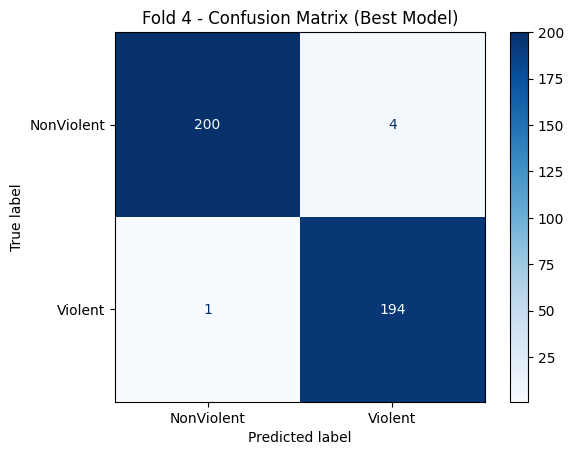

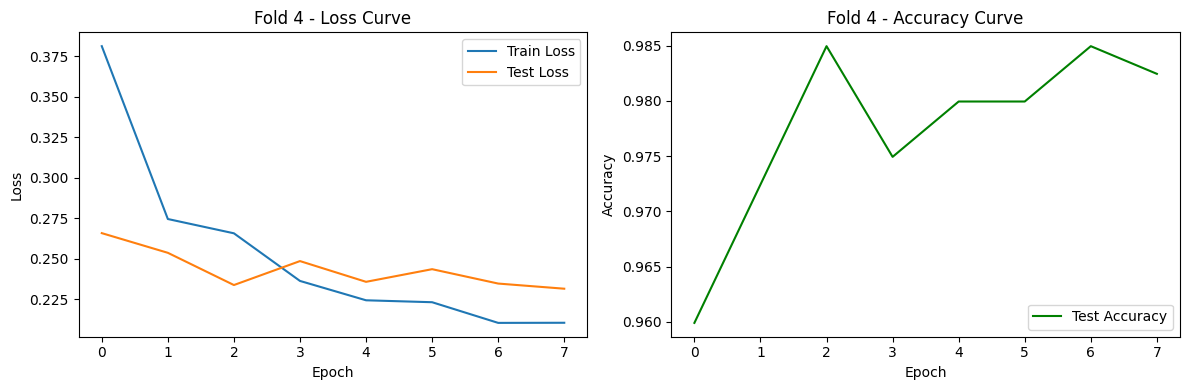

🔁 بدء التدريب - Fold 5


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
[Fold 5] Epoch 1/30 [Val]: 100%|██████████| 50/50 [00:41<00:00,  1.21it/s]



📊 Fold 5 | Epoch 1
📉 Train Loss: 0.3706 | ✅ Train Acc: 0.8924
🧪  Val Loss : 0.2633 | 🎯 Val Acc  : 0.9674
💾 أفضل نموذج تم حفظه.


[Fold 5] Epoch 2/30 [Val]: 100%|██████████| 50/50 [00:40<00:00,  1.23it/s]



📊 Fold 5 | Epoch 2
📉 Train Loss: 0.2878 | ✅ Train Acc: 0.9537
🧪  Val Loss : 0.2413 | 🎯 Val Acc  : 0.9724
💾 أفضل نموذج تم حفظه.


...


📊 Fold 5 | Epoch 9
📉 Train Loss: 0.2033 | ✅ Train Acc: 0.9981
🧪  Val Loss : 0.2514 | 🎯 Val Acc  : 0.9774


[Fold 5] Epoch 10/30 [Val]: 100%|██████████| 50/50 [00:41<00:00,  1.22it/s]



📊 Fold 5 | Epoch 10
📉 Train Loss: 0.2065 | ✅ Train Acc: 0.9962
🧪  Val Loss : 0.2493 | 🎯 Val Acc  : 0.9749


[Fold 5] Epoch 11/30 [Val]: 100%|██████████| 50/50 [00:40<00:00,  1.22it/s]



📊 Fold 5 | Epoch 11
📉 Train Loss: 0.2057 | ✅ Train Acc: 0.9969
🧪  Val Loss : 0.2548 | 🎯 Val Acc  : 0.9749
⏹️ تم التوقف المبكر.

------------------------------------------------------------
📄 تقرير التصنيف - Fold 5 (بعد تحميل أفضل وزن)
------------------------------------------------------------
              precision    recall  f1-score   support

  NonViolent       0.97      0.99      0.98       181
     Violent       0.99      0.97      0.98       218

    accuracy                           0.98       399
   macro avg       0.98      0.98      0.98       399
weighted avg       0.98      0.98      0.98       399



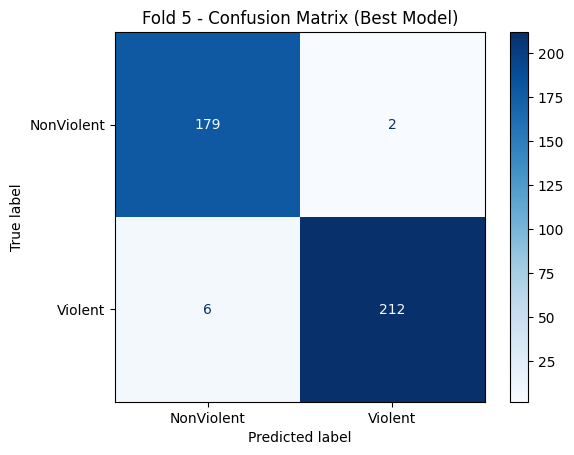

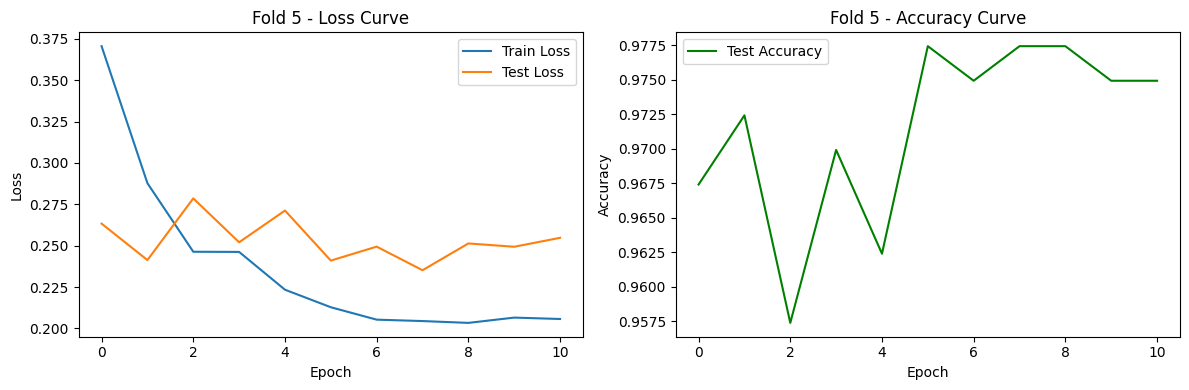

📊 Accuracy Ortalamasi 5 Folds: 0.9815
📉 Standart sapma (Standard Deviation): 0.0075


In [17]:
import os
import gc
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch import nn, optim
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import KFold
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EPOCHS = 30
BATCH_SIZE = 8
PATIENCE = 5
k_folds = 5

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
all_fold_acc = []
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
indices = list(range(len(dataset)))  # تأكد أن dataset معرف مسبقاً
save_path = "/content/drive/MyDrive"

for fold, (train_idx, val_idx) in enumerate(kf.split(indices)):
    print("=" * 60)
    print(f"🔁 بدء التدريب - Fold {fold + 1}")
    print("=" * 60)

    train_loader = DataLoader(Subset(dataset, train_idx), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(Subset(dataset, val_idx), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    model = MoBiLSTM().to(device)  # تأكد أن MoBiLSTM معرف مسبقاً
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)

    best_acc = 0
    early_stop = 0
    train_losses, val_losses, val_accuracies = [], [], []

    for epoch in range(EPOCHS):
        model.train()
        total_loss, correct_train, total_train = 0, 0, 0
        for X, y in tqdm(train_loader, desc=f"[Fold {fold+1}] Epoch {epoch+1}/{EPOCHS} [Train]"):
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
            preds = torch.argmax(out, dim=1)
            correct_train += (preds == y).sum().item()
            total_train += y.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc = correct_train / total_train
        train_losses.append(train_loss)

        model.eval()
        val_loss, val_preds, val_labels = 0, [], []
        correct_val, total_val = 0, 0
        with torch.no_grad():
            for X, y in tqdm(val_loader, desc=f"[Fold {fold+1}] Epoch {epoch+1}/{EPOCHS} [Val]"):
                X, y = X.to(device), y.to(device)
                out = model(X)
                loss = criterion(out, y)
                val_loss += loss.item()
                pred = torch.argmax(out, dim=1)
                val_preds.extend(pred.cpu().numpy())
                val_labels.extend(y.cpu().numpy())
                correct_val += (pred == y).sum().item()
                total_val += y.size(0)

        val_loss /= len(val_loader)
        val_acc = correct_val / total_val
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        scheduler.step(val_loss)

        print(f"\n📊 Fold {fold+1} | Epoch {epoch+1}")
        print(f"📉 Train Loss: {train_loss:.4f} | ✅ Train Acc: {train_acc:.4f}")
        print(f"🧪  Val Loss : {val_loss:.4f} | 🎯 Val Acc  : {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f"{save_path}/resnet_bilstm_fold{fold+1}.pth")
            early_stop = 0
            print("💾 أفضل نموذج تم حفظه.")
        else:
            early_stop += 1
            if early_stop >= PATIENCE:
                print("⏹️ تم التوقف المبكر.")
                break

    # 🔄 تحميل أفضل نموذج للتقييم
    model.load_state_dict(torch.load(f"{save_path}/resnet_bilstm_fold{fold+1}.pth"))
    model.eval()

    # إعادة التقييم باستخدام الوزن الأفضل
    val_preds, val_labels = [], []
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            pred = torch.argmax(out, dim=1)
            val_preds.extend(pred.cpu().numpy())
            val_labels.extend(y.cpu().numpy())

    # 📄 تقرير التصنيف النهائي
    print("\n" + "-"*60)
    print(f"📄 تقرير التصنيف - Fold {fold+1} (بعد تحميل أفضل وزن)")
    print("-"*60)
    print(classification_report(val_labels, val_preds, target_names=["NonViolent", "Violent"]))

    # 🔲 مصفوفة الالتباس
    cm = confusion_matrix(val_labels, val_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NonViolent", "Violent"])
    disp.plot(cmap="Blues", values_format='d')
    plt.title(f"Fold {fold+1} - Confusion Matrix (Best Model)")
    plt.show()

    # منحنيات التدريب
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Fold {fold+1} - Loss Curve")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(val_accuracies, label="Test Accuracy", color='green')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Fold {fold+1} - Accuracy Curve")
    plt.legend()

    plt.tight_layout()
    plt.show()

    all_fold_acc.append(best_acc)
    gc.collect()
    torch.cuda.empty_cache()

# ✅ المتوسط والانحراف المعياري عبر 5 Folds
mean_acc = np.mean(all_fold_acc)
std_acc = np.std(all_fold_acc)

print(f"📊 Accuracy Ortalamasi 5 Folds: {mean_acc:.4f}")
print(f"📉 Standart sapma (Standard Deviation): {std_acc:.4f}")



🔄 تقييم Fold 1

🔄 تقييم Fold 2

🔄 تقييم Fold 3

🔄 تقييم Fold 4

🔄 تقييم Fold 5
      Fold  Accuracy  Precision  Recall
0   Fold 1    0.9925     0.9948  0.9896
1   Fold 2    0.9825     0.9762  0.9903
2   Fold 3    0.9699     0.9628  0.9731
3   Fold 4    0.9850     0.9749  0.9949
4   Fold 5    0.9799     0.9907  0.9725
5  Average    0.9820     0.9799  0.9841


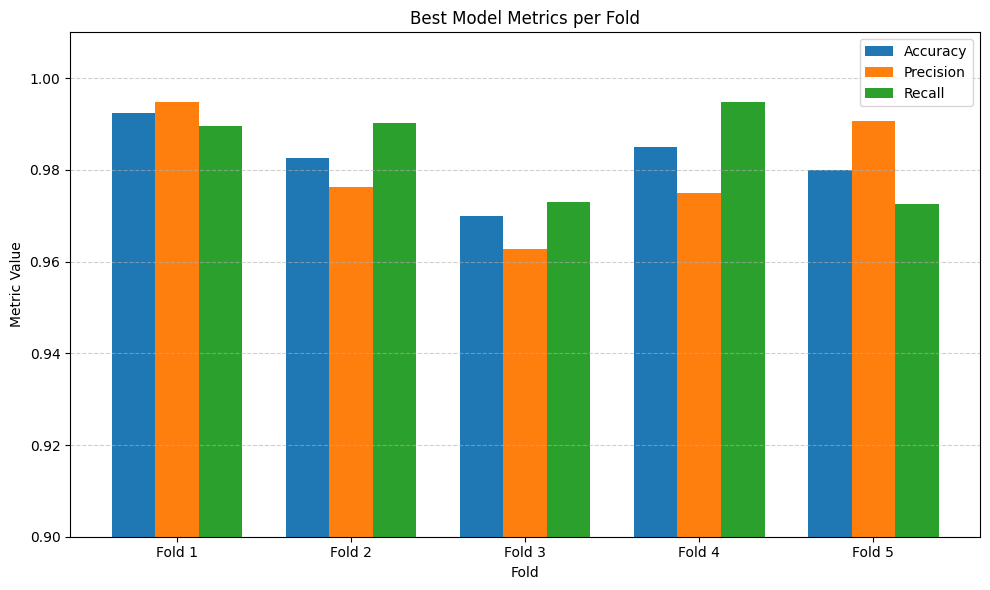

In [18]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import KFold

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

all_folds_data = []

# توليد الفهارس من جديد بناءً على dataset
k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
indices = list(range(len(dataset)))
val_idx_list = [val_idx for _, val_idx in kf.split(indices)]

for fold in range(5):
    print(f"\n🔄 تقييم Fold {fold+1}")

    val_loader = DataLoader(Subset(dataset, val_idx_list[fold]), batch_size=8, shuffle=False)

    # تحميل النموذج
    model = MoBiLSTM().to(device)
    model.load_state_dict(torch.load(f"/content/drive/MyDrive/resnet_bilstm_fold{fold+1}.pth"))
    model.eval()

    val_preds = []
    val_labels = []

    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            pred = torch.argmax(out, dim=1)
            val_preds.extend(pred.cpu().numpy())
            val_labels.extend(y.cpu().numpy())

    acc = accuracy_score(val_labels, val_preds)
    prec = precision_score(val_labels, val_preds)
    rec = recall_score(val_labels, val_preds)

    all_folds_data.append({
        "Fold": f"Fold {fold+1}",
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec
    })

# حساب المتوسط
df = pd.DataFrame(all_folds_data)
avg = {
    "Fold": "Average",
    "Accuracy": df["Accuracy"].mean(),
    "Precision": df["Precision"].mean(),
    "Recall": df["Recall"].mean()
}
df = pd.concat([df, pd.DataFrame([avg])], ignore_index=True)
df[["Accuracy", "Precision", "Recall"]] = df[["Accuracy", "Precision", "Recall"]].round(4)

print(df)

# رسم
x = range(len(df) - 1)
bar_width = 0.25

plt.figure(figsize=(10, 6))
plt.bar([i - bar_width for i in x], df["Accuracy"][:-1], width=bar_width, label="Accuracy")
plt.bar(x, df["Precision"][:-1], width=bar_width, label="Precision")
plt.bar([i + bar_width for i in x], df["Recall"][:-1], width=bar_width, label="Recall")

plt.xticks(ticks=x, labels=df["Fold"][:-1])
plt.xlabel("Fold")
plt.ylabel("Metric Value")
plt.title("Best Model Metrics per Fold")
plt.ylim(0.9, 1.01)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
